# ✍️ Bài 7: Ứng dụng — Tiền Xử Lý Tách Chữ Viết Tay (OCR)
**Môn học**: E1402 - Computer Vision  
**Chủ đề**: Tiền xử lý ảnh cho nhận dạng ký tự quang học (OCR)

---

### 🎯 Mục tiêu bài học:
- Hiểu pipeline tiền xử lý ảnh chữ viết tay
- So sánh **Otsu Threshold** (toàn cục) vs **Adaptive Threshold** (cục bộ)
- Biết khi nào dùng phương pháp nào
- Thực hành **Morphological Operations** để làm sạch ảnh

### 📋 Kiến thức cần có:
- Bài 5: Các hệ màu cơ bản (RGB, Grayscale, Binary)

---
## ⚙️ Phần 1: Cài đặt thư viện

In [1]:
import cv2                          # OpenCV - thư viện xử lý ảnh chính
import numpy as np                  # NumPy - xử lý mảng số
import matplotlib.pyplot as plt     # Matplotlib - hiển thị ảnh
import random                       # Random - tạo dữ liệu ngẫu nhiên
import urllib.request               # Tải ảnh từ URL

# Kiểm tra môi trường
try:
    import google.colab
    COLAB = True
    print('✅ Đang chạy trên Google Colab')
except:
    COLAB = False
    print('✅ Đang chạy trên máy local')

# --- Hàm tiện ích ---
def tai_anh_url(url):
    """Tải ảnh từ URL và trả về dạng BGR (OpenCV)"""
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urllib.request.urlopen(req)
    arr = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def hien_thi(ds_anh, ds_ten, figsize=(15, 5), cmap_list=None):
    """Hiển thị nhiều ảnh cạnh nhau"""
    n = len(ds_anh)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, (anh, ten) in enumerate(zip(ds_anh, ds_ten)):
        cmap = cmap_list[i] if cmap_list else None
        if cmap is None and len(anh.shape) == 3:
            axes[i].imshow(cv2.cvtColor(anh, cv2.COLOR_BGR2RGB))
        else:
            axes[i].imshow(anh, cmap=cmap)
        axes[i].set_title(ten, fontsize=12, fontweight='bold')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

print('📦 Đã import xong tất cả thư viện!')

✅ Đang chạy trên máy local
📦 Đã import xong tất cả thư viện!


---
## 📖 Phần 2: Lý thuyết — Ngưỡng hóa cho OCR

### 2.1 Vấn đề với ảnh chữ viết tay
Ảnh chụp tài liệu thường có **ánh sáng không đều**:
- Góc trên sáng, góc dưới tối
- Bóng đổ từ tay/sách
- Đèn flash phản chiếu

### 2.2 So sánh 2 phương pháp ngưỡng hóa

| | **Otsu** (Toàn cục) | **Adaptive** (Cục bộ) |
|---|---|---|
| **Ngưỡng** | 1 giá trị cho toàn bộ ảnh | Ngưỡng riêng cho từng vùng nhỏ |
| **Cách tính** | Dựa trên histogram toàn ảnh | Dựa trên mean/gaussian vùng lân cận |
| **Ưu điểm** | Đơn giản, nhanh | Bền vững với ánh sáng không đều |
| **Nhược điểm** | Hỏng khi sáng không đều | Cần chỉnh 2 tham số |
| **Khi nào dùng** | Ảnh sáng đều, scan | Ảnh chụp tay, ánh sáng tự nhiên |

### 2.3 Tham số Adaptive Threshold
```python
cv2.adaptiveThreshold(img, maxValue=255,
    adaptiveMethod = cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # Gaussian weighting
    thresholdType  = cv2.THRESH_BINARY,               # Trắng/đen
    blockSize      = 21,    # Kích thước vùng cục bộ (phải là SỐ LẺ)
    C              = 10)    # Hằng số trừ đi (điều chỉnh độ nhạy)
```

> 💡 **blockSize** lớn = mượt hơn nhưng mất nét nhỏ. **C** lớn = ít nhiễu nhưng có thể mất nét mảnh.

---
## 🧪 Phần 3: Tạo dữ liệu — Mô phỏng ảnh chữ viết tay

Ta tạo ảnh mô phỏng một trang giấy có chữ viết tay với đặc điểm:
- **Nền giấy vàng nhẹ** (giống giấy cũ)
- **Ánh sáng KHÔNG đều** (sáng ở trên-trái, tối ở dưới-phải → gradient)
- **Nhiễu texture** giấy
- **Chữ viết tay** với độ đậm/mảnh khác nhau

> 🔑 Phần tạo dữ liệu **tách riêng** để dễ thay thế bằng ảnh thực tế.

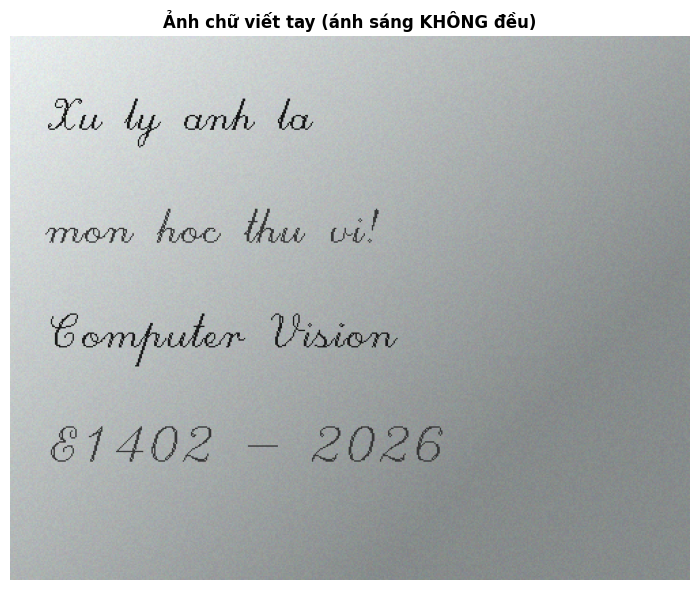

📋 Kích thước ảnh: (400, 500, 3)
💡 Chú ý: Góc trên-trái SÁNG hơn góc dưới-phải → thách thức cho ngưỡng hóa!


In [2]:
# ============================================================
# 📂 TẠO DỮ LIỆU: Mô phỏng ảnh chữ viết tay trên giấy
# ============================================================
random.seed(42)

def tao_anh_chu_viet_tay(kich_thuoc=(400, 500)):
    """
    Tạo ảnh mô phỏng trang giấy có chữ viết tay.
    Ánh sáng KHÔNG đều (gradient) để demo Adaptive vs Otsu.
    
    Tham số:
        kich_thuoc: (chiều cao, chiều rộng)
    Trả về:
        anh: ảnh BGR
    """
    h, w = kich_thuoc
    anh = np.zeros((h, w, 3), dtype=np.uint8)
    
    # Tạo nền có gradient (ánh sáng không đều)
    for y in range(h):
        for x in range(w):
            # Sáng ở trên-trái, tối ở dưới-phải
            val = int(240 - (x + y) * 0.15)
            val = max(140, min(250, val))
            anh[y, x] = (val, val, val - 5)  # Hơi vàng nhẹ
    
    # Thêm nhiễu texture giấy
    nhieu = np.random.randint(-8, 8, anh.shape, dtype=np.int16)
    anh = np.clip(anh.astype(np.int16) + nhieu, 0, 255).astype(np.uint8)
    
    # Viết chữ (mô phỏng chữ viết tay)
    font = cv2.FONT_HERSHEY_SCRIPT_COMPLEX  # Font giống viết tay
    cac_dong = [
        'Xu ly anh la',
        'mon hoc thu vi!',
        'Computer Vision',
        'E1402 - 2026'
    ]
    
    y_start = 70
    for i, dong in enumerate(cac_dong):
        y_pos = y_start + i * 80
        do_dam = random.randint(1, 2)
        mau_muc = random.randint(20, 60)  # Mực đen/xám đậm
        # Thêm jitter nhẹ (tay run)
        dx = random.randint(-5, 5)
        dy = random.randint(-3, 3)
        scale = 1.0 + random.random() * 0.3
        cv2.putText(anh, dong, (30 + dx, y_pos + dy),
                    font, scale, (mau_muc, mau_muc, mau_muc), do_dam)
    
    return anh

# --- Tạo ảnh mô phỏng ---
anh_viet_tay = tao_anh_chu_viet_tay()

hien_thi([anh_viet_tay], 
         ['Ảnh chữ viết tay (ánh sáng KHÔNG đều)'], 
         figsize=(8, 6))
print(f'📋 Kích thước ảnh: {anh_viet_tay.shape}')
print(f'💡 Chú ý: Góc trên-trái SÁNG hơn góc dưới-phải → thách thức cho ngưỡng hóa!')

---
## 🔬 Phần 4: Xử lý — So sánh Otsu vs Adaptive Threshold

Ta sẽ áp dụng **cả hai phương pháp** lên cùng ảnh để thấy sự khác biệt.

In [3]:
# ============================================================
# 🔬 XỬ LÝ: So sánh Otsu vs Adaptive Threshold
# ============================================================

# --- Bước 1: Chuyển sang ảnh xám ---
anh_xam = cv2.cvtColor(anh_viet_tay, cv2.COLOR_BGR2GRAY)
print(f'Bước 1: Ảnh xám — min={anh_xam.min()}, max={anh_xam.max()}')

# --- Bước 2a: Otsu Threshold (TOÀN CỤC) ---
nguong_otsu, anh_otsu = cv2.threshold(
    anh_xam, 0, 255, 
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f'Bước 2a: Otsu — ngưỡng toàn cục = {nguong_otsu:.0f}')

# --- Bước 2b: Adaptive Threshold (CỤC BỘ) ---
BLOCK_SIZE = 21  # Kích thước vùng cục bộ (số lẻ)
C_VALUE = 10     # Hằng số trừ

anh_adaptive = cv2.adaptiveThreshold(
    anh_xam, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=BLOCK_SIZE,
    C=C_VALUE
)
print(f'Bước 2b: Adaptive — blockSize={BLOCK_SIZE}, C={C_VALUE}')

# --- Bước 3: Làm sạch bằng Morphology ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
anh_sach = cv2.morphologyEx(anh_adaptive, cv2.MORPH_CLOSE, kernel, iterations=1)
print(f'Bước 3: Morphology CLOSE — loại nhiễu nhỏ')

Bước 1: Ảnh xám — min=21, max=242
Bước 2a: Otsu — ngưỡng toàn cục = 170
Bước 2b: Adaptive — blockSize=21, C=10
Bước 3: Morphology CLOSE — loại nhiễu nhỏ


---
## 📊 Phần 5: Kết quả — So sánh trực quan

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6762/2115202050.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6762/2115202050.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/phongdang/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/phongdang/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


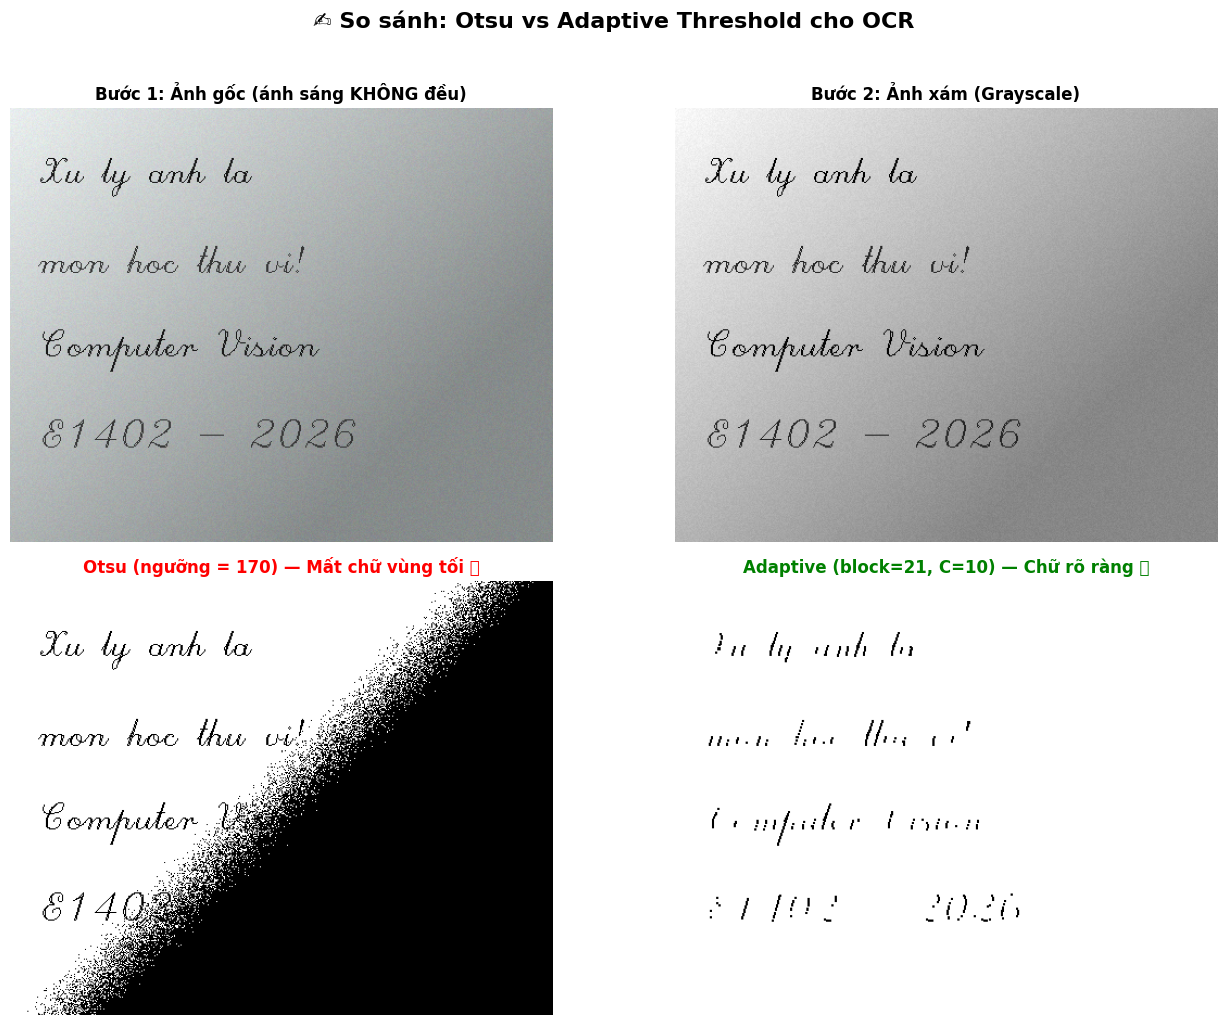

📊 Phân tích:
  Otsu (toàn cục):  Dùng ngưỡng = 170 cho TOÀN BỘ ảnh
                    → Vùng tối (dưới-phải): mất chữ!
                    → Vùng sáng (trên-trái): nhiễu nền!
  Adaptive (cục bộ): Tính ngưỡng riêng cho từng ô 21x21
                    → Chữ tách rõ ràng ở MỌI vùng!


In [4]:
# ============================================================
# 📊 HIỂN THỊ: So sánh Otsu vs Adaptive
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].imshow(cv2.cvtColor(anh_viet_tay, cv2.COLOR_BGR2RGB))
axes[0][0].set_title('Bước 1: Ảnh gốc (ánh sáng KHÔNG đều)', 
                     fontsize=12, fontweight='bold')

axes[0][1].imshow(anh_xam, cmap='gray')
axes[0][1].set_title('Bước 2: Ảnh xám (Grayscale)', 
                     fontsize=12, fontweight='bold')

axes[1][0].imshow(anh_otsu, cmap='gray')
axes[1][0].set_title(f'Otsu (ngưỡng = {nguong_otsu:.0f}) — Mất chữ vùng tối ❌', 
                     fontsize=12, fontweight='bold', color='red')

axes[1][1].imshow(anh_sach, cmap='gray')
axes[1][1].set_title(f'Adaptive (block={BLOCK_SIZE}, C={C_VALUE}) — Chữ rõ ràng ✅', 
                     fontsize=12, fontweight='bold', color='green')

for row in axes:
    for ax in row:
        ax.axis('off')

plt.suptitle('✍️ So sánh: Otsu vs Adaptive Threshold cho OCR', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📊 Phân tích:')
print(f'  Otsu (toàn cục):  Dùng ngưỡng = {nguong_otsu:.0f} cho TOÀN BỘ ảnh')
print(f'                    → Vùng tối (dưới-phải): mất chữ!')
print(f'                    → Vùng sáng (trên-trái): nhiễu nền!')
print(f'  Adaptive (cục bộ): Tính ngưỡng riêng cho từng ô {BLOCK_SIZE}x{BLOCK_SIZE}')
print(f'                    → Chữ tách rõ ràng ở MỌI vùng!')

---
## 🧪 Phần 6: Thử nghiệm — Thay đổi tham số Adaptive Threshold

Hãy thay đổi `blockSize` và `C` để hiểu ảnh hưởng của từng tham số.

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6762/1979437728.py:27: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/phongdang/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


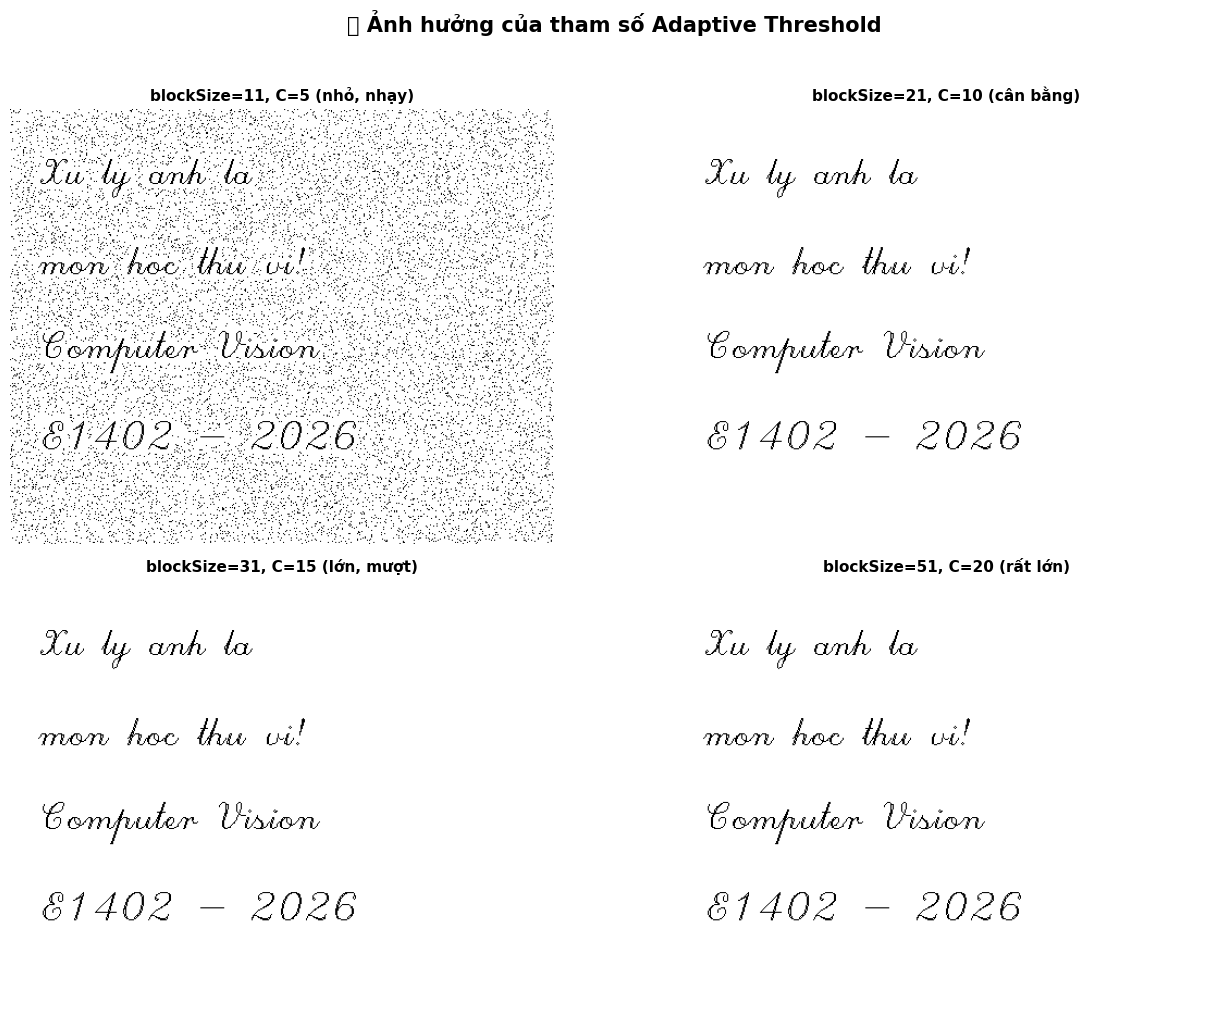

💡 Quan sát:
  • blockSize NHỎ → nhiều chi tiết nhưng NHIỀU NHIỄU
  • blockSize LỚN → mượt hơn nhưng MẤT NÉT MẢNH
  • C NHỎ → nhạy (bắt được nét mờ) nhưng NHIỀU NHIỄU
  • C LỚN → ít nhiễu nhưng có thể BỎ SÓT nét mảnh
  
👉 Tổ hợp tối ưu phổ biến: blockSize=21, C=10


In [5]:
# ============================================================
# 🔧 THỬ NGHIỆM: Ảnh hưởng của tham số blockSize và C
# ============================================================

xam = cv2.cvtColor(anh_viet_tay, cv2.COLOR_BGR2GRAY)

# Thử nhiều tổ hợp tham số
tham_so = [
    (11, 5,  'blockSize=11, C=5 (nhỏ, nhạy)'),
    (21, 10, 'blockSize=21, C=10 (cân bằng)'),
    (31, 15, 'blockSize=31, C=15 (lớn, mượt)'),
    (51, 20, 'blockSize=51, C=20 (rất lớn)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (block, c, title) in enumerate(tham_so):
    r, col = idx // 2, idx % 2
    result = cv2.adaptiveThreshold(xam, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block, c)
    axes[r][col].imshow(result, cmap='gray')
    axes[r][col].set_title(title, fontsize=11, fontweight='bold')
    axes[r][col].axis('off')

plt.suptitle('🔧 Ảnh hưởng của tham số Adaptive Threshold', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Quan sát:')
print('  • blockSize NHỎ → nhiều chi tiết nhưng NHIỀU NHIỄU')
print('  • blockSize LỚN → mượt hơn nhưng MẤT NÉT MẢNH')
print('  • C NHỎ → nhạy (bắt được nét mờ) nhưng NHIỀU NHIỄU')
print('  • C LỚN → ít nhiễu nhưng có thể BỎ SÓT nét mảnh')
print('  \n👉 Tổ hợp tối ưu phổ biến: blockSize=21, C=10')

---
## 📝 Tổng kết

### Pipeline tiền xử lý OCR:
```
Ảnh chữ viết tay → Grayscale → Adaptive Threshold → Morphology → Ảnh sạch cho OCR
```

### Các hàm OpenCV quan trọng:
| Hàm | Chức năng |
|---|---|
| `cv2.threshold(..., THRESH_OTSU)` | Ngưỡng Otsu (toàn cục, tự động) |
| `cv2.adaptiveThreshold(...)` | Ngưỡng cục bộ (tốt hơn cho OCR) |
| `cv2.morphologyEx(img, MORPH_CLOSE, kernel)` | Nối các nét bị đứt |

### Quy tắc chọn phương pháp:
| Tình huống | Dùng |
|---|---|
| Ảnh scan (sáng đều) | Otsu |
| Ảnh chụp điện thoại | **Adaptive** |
| Tài liệu bóng đổ | **Adaptive** |
| Ảnh X-quang/y khoa | Otsu (thường sáng đều) |

### Lưu ý thực tế:
- Trong OCR thực tế, sau bước này còn cần: **deskew** (thẳng chữ), **denoising** (lọc nhiễu), **segmentation** (tách từng ký tự)
- Các engine OCR phổ biến: **Tesseract**, **EasyOCR**, **PaddleOCR**
- Deep Learning OCR (CRNN, TrOCR) thường tự xử lý tiền xử lý bên trong